In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('omega_class_moments_N1e6.csv')
print(df.shape)
df

(12, 15)


,L_function,N_terms,M_total,M_0,M_1,M_2,M_3,M_4,M_geq5,frac_0,frac_1,frac_2,frac_3,frac_4,frac_geq5
0,zeta,10000,14049.610398,500.0,1965.747008,6483.537674,4759.568118,337.922395,2.835203,0.035588,0.139915,0.461475,0.338769,0.024052,0.000202
1,zeta,50000,52555.776641,500.0,3208.301641,21414.200073,24096.365734,3301.861669,35.047524,0.009514,0.061046,0.407457,0.458491,0.062826,0.000667
2,zeta,100000,98775.232940,500.0,4480.038022,37384.580762,48011.972434,8267.691145,130.950577,0.005062,0.045356,0.378481,0.486073,0.083702,0.001326
3,L(Δ),10000,2161.019922,500.0,976.303859,566.192078,113.409894,5.078208,0.035883,0.231372,0.451779,0.262002,0.052480,0.002350,0.000017
4,L(Δ),50000,2348.222814,500.0,1033.094242,641.389207,159.091605,14.413875,0.233885,0.212927,0.439947,0.273138,0.067750,0.006138,0.000100
5,L(Δ),100000,2428.171224,500.0,1050.861296,676.608911,181.308525,18.942436,0.450056,0.205916,0.432779,0.278650,0.074669,0.007801,0.000185
6,L_DH,10000,2025.689869,500.0,618.478717,717.769427,168.571130,20.716949,0.153646,0.246829,0.305318,0.354333,0.083217,0.010227,0.000076
7,L_DH,50000,2186.052439,500.0,639.066491,784.006896,226.647968,34.942774,1.388309,0.228723,0.292338,0.358640,0.103679,0.015984,0.000635
8,L_DH,100000,2238.888403,500.0,644.808316,800.888886,246.569721,44.398665,2.222815,0.223325,0.288004,0.357717,0.110130,0.019831,0.000993
9,zeta,1000000,884001.871616,500.0,21169.883300,264592.121329,453548.637660,137448.741642,6742.487684,0.000566,0.023948,0.299312,0.513063,0.155485,0.007627


In [2]:
from scipy import stats

def fit_model(N_vals, M_vals):
 x = np.log(np.log(N_vals))
 y = np.log(M_vals)
 n = len(x)
 res = stats.linregress(x, y)
 # 95% CI for slope using t-distribution, df = n-2
 tcrit = stats.t.ppf(0.975, n-2)
 ci_half = tcrit * res.stderr
 return {
 'slope': res.slope,
 'intercept': res.intercept,
 'r2': res.rvalue**2,
 'stderr': res.stderr,
 'ci_low': res.slope - ci_half,
 'ci_high': res.slope + ci_half,
 'n': n,
 'pvalue': res.pvalue,
 }

results = []
for L in ['L(Δ)', 'L_DH']:
 sub = df[df['L_function'] == L].sort_values('N_terms')
 N_vals = sub['N_terms'].values.astype(float)
 print(f"{L}: N = {N_vals}")
 for k in [1,2,3,4]:
 col = f'M_{k}'
 M_vals = sub[col].values.astype(float)
 r = fit_model(N_vals, M_vals)
 r['L'] = L
 r['k'] = k
 results.append(r)

res_df = pd.DataFrame(results)
res_df

L(Δ): N = [ 10000. 50000. 100000. 1000000.]
L_DH: N = [ 10000. 50000. 100000. 1000000.]


,slope,intercept,r2,stderr,ci_low,ci_high,n,pvalue,L,k
0,0.289281,6.246380,0.988089,0.022458,0.192652,0.385910,4,0.005973,L(Δ),1
1,0.798012,4.565984,0.999810,0.007772,0.764571,0.831453,4,0.000095,L(Δ),2
2,2.022539,0.247970,0.999283,0.038310,1.857702,2.187376,4,0.000359,L(Δ),3
3,4.821428,-8.949139,0.969974,0.599830,2.240569,7.402287,4,0.015127,L(Δ),4
4,0.170682,6.050626,0.992290,0.010639,0.124908,0.216456,4,0.003862,L_DH,1
5,0.480114,5.513888,0.996298,0.020695,0.391072,0.569156,4,0.001853,L_DH,2
6,1.565975,1.670017,0.993524,0.089397,1.181330,1.950619,4,0.003243,L_DH,3
7,3.065841,-3.750580,0.994551,0.160467,2.375407,3.756276,4,0.002728,L_DH,4


In [3]:
ldelta = res_df[res_df['L']=='L(Δ)'].set_index('k')
ldh = res_df[res_df['L']=='L_DH'].set_index('k')

compare = pd.DataFrame({
 'k': [1,2,3,4],
 'a_LDelta': ldelta['slope'].values,
 'CI_LDelta': [f"[{ldelta.loc[k,'ci_low']:.3f}, {ldelta.loc[k,'ci_high']:.3f}]" for k in [1,2,3,4]],
 'R2_LDelta': ldelta['r2'].values,
 'a_LDH': ldh['slope'].values,
 'CI_LDH': [f"[{ldh.loc[k,'ci_low']:.3f}, {ldh.loc[k,'ci_high']:.3f}]" for k in [1,2,3,4]],
 'R2_LDH': ldh['r2'].values,
})

# Check disjointness
disjoint = []
for k in [1,2,3,4]:
 ld_lo, ld_hi = ldelta.loc[k,'ci_low'], ldelta.loc[k,'ci_high']
 dh_lo, dh_hi = ldh.loc[k,'ci_low'], ldh.loc[k,'ci_high']
 is_disjoint = (ld_hi < dh_lo) or (dh_hi < ld_lo)
 disjoint.append(is_disjoint)
compare['disjoint_95CI'] = disjoint
compare

,k,a_LDelta,CI_LDelta,R2_LDelta,a_LDH,CI_LDH,R2_LDH,disjoint_95CI
0,1,0.289281,"[0.193, 0.386]",0.988089,0.170682,"[0.125, 0.216]",0.992290,False
1,2,0.798012,"[0.765, 0.831]",0.999810,0.480114,"[0.391, 0.569]",0.996298,True
2,3,2.022539,"[1.858, 2.187]",0.999283,1.565975,"[1.181, 1.951]",0.993524,False
3,4,4.821428,"[2.241, 7.402]",0.969974,3.065841,"[2.375, 3.756]",0.994551,False


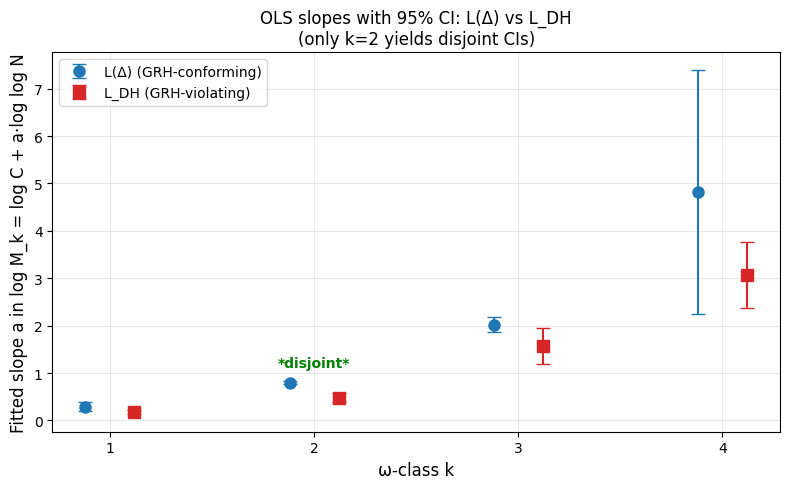

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ks = np.array([1,2,3,4])
offset = 0.12

ld_slopes = ldelta.loc[ks,'slope'].values
ld_lo = ldelta.loc[ks,'ci_low'].values
ld_hi = ldelta.loc[ks,'ci_high'].values
dh_slopes = ldh.loc[ks,'slope'].values
dh_lo = ldh.loc[ks,'ci_low'].values
dh_hi = ldh.loc[ks,'ci_high'].values

ax.errorbar(ks - offset, ld_slopes, yerr=[ld_slopes-ld_lo, ld_hi-ld_slopes],
 fmt='o', capsize=5, color='C0', label='L(Δ) (GRH-conforming)', markersize=8)
ax.errorbar(ks + offset, dh_slopes, yerr=[dh_slopes-dh_lo, dh_hi-dh_slopes],
 fmt='s', capsize=5, color='C3', label='L_DH (GRH-violating)', markersize=8)

# Mark disjoint k
for i,k in enumerate(ks):
 if disjoint[i]:
 ax.annotate('*disjoint*', (k, max(ld_hi[i], dh_hi[i])+0.3),
 ha='center', fontsize=10, color='green', fontweight='bold')

ax.set_xlabel('ω-class k', fontsize=12)
ax.set_ylabel('Fitted slope a in log M_k = log C + a·log log N', fontsize=12)
ax.set_title('OLS slopes with 95% CI: L(Δ) vs L_DH\n(only k=2 yields disjoint CIs)', fontsize=12)
ax.set_xticks(ks)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('omega_slope_comparison.png', dpi=130)
plt.show()

In [5]:
res_df.to_csv('omega_slope_fits_LDelta_vs_LDH.csv', index=False)
compare.to_csv('omega_slope_comparison_table.csv', index=False)
print("Saved.")

Saved.
